# U-Net with ResNet50 Transfer Learning (RadImageNet)

## Architecture Overview

**ResNet50** encoder pretrained on RadImageNet with U-Net decoder:
- ✅ Powerful ResNet50 backbone (151M parameters in encoder)
- ✅ RadImageNet weights (medical imaging pretraining)
- ✅ Skip connections from intermediate layers
- ✅ Simple decoder with concatenation

## Training Strategy
1. **Phase 1 (25 epochs):** Encoder frozen → Learn decoder only
2. **Phase 2 (10 epochs):** Fine-tune top 30 encoder layers with LR = 1e-5

In [2]:
# Install dependencies
%pip install numpy tensorflow nibabel matplotlib scikit-image scipy --quiet
print("✔ Libraries installed")

Note: you may need to restart the kernel to use updated packages.
✔ Libraries installed


In [1]:
# =============================================================
# 0. IMPORTS
# =============================================================

import os
import numpy as np
import nibabel as nib
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy import ndimage
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✔ All libraries imported")
print(f"   TensorFlow: {tf.__version__}")

✔ All libraries imported
   TensorFlow: 2.19.0


In [2]:
# =============================================================
# 1. DATASET CONFIGURATION
# =============================================================

DATASET_PATH = "DATASET_TRAINING"
IMG_TARGET = 120
BATCH_SIZE = 4

# -------------------------------------------------------------
# CONFIGURACIÓN DEL ENTRENAMIENTO
# -------------------------------------------------------------
# Opciones:
#   "cerebro"  -> segmentar la máscara de cerebro
#   "isquemia" -> segmentar la máscara de isquemia
TRAIN_TARGET = "cerebro"

# Si es True, la imagen MRI se multiplica por la máscara de cerebro
# antes de entrenar. Útil normalmente para isquemia.
APPLY_BRAIN_MASK = False

# Nombre base del modelo guardado
MODEL_NAME = f"{TRAIN_TARGET}_segmentatio_model_RadImageNET.h5"

print("📁 Dataset configurado.")
print(f"🎯 Objetivo de segmentación: {TRAIN_TARGET}")
print(f"🧠 Aplicar máscara de cerebro a la imagen: {APPLY_BRAIN_MASK}")


📁 Dataset configurado.


In [3]:
# =============================================================
# 2a. HELPER FUNCTIONS
# =============================================================

def load_nifti_slices(nifti_path):
    """Load NIfTI and normalize to 0-1."""
    nii = nib.load(nifti_path)
    vol = nii.get_fdata()
    vol = (vol - np.min(vol)) / (np.max(vol) - np.min(vol))
    vol = np.rot90(vol, k=3, axes=(0, 1))
    vol = np.flip(vol, axis=1)
    return vol

def load_mask(mask_path):
    """Load PNG mask and convert to binary."""
    img = Image.open(mask_path).convert("L")
    mask = np.array(img, dtype=np.uint8)
    mask = (mask > 127).astype(np.uint8)
    return mask

print("✅ Helper functions defined")

✅ Helper functions defined


In [4]:
# =============================================================
# 2. LOAD & AUGMENT DATA
# =============================================================

def load_nifti_slices(nifti_path):
    """Load NIfTI and normalize to 0-1."""
    nii = nib.load(nifti_path)
    vol = nii.get_fdata()

    vol_min, vol_max = np.min(vol), np.max(vol)
    if vol_max > vol_min:
        vol = (vol - vol_min) / (vol_max - vol_min)
    else:
        vol = np.zeros_like(vol, dtype=np.float32)

    vol = np.rot90(vol, k=3, axes=(0, 1))
    vol = np.flip(vol, axis=1)
    return vol

def load_mask(mask_path):
    """Load PNG mask and convert to binary."""
    img = Image.open(mask_path).convert("L")
    mask = np.array(img, dtype=np.uint8)
    mask = (mask > 127).astype(np.uint8)
    return mask

def find_nifti_file(case_path):
    """Busca el archivo NIfTI tolerando diferencias de mayúsculas/minúsculas."""
    candidates = [
        "Seq No.nii",
        "seq NO.nii",
        "seq No.nii",
        "SEQ NO.nii",
    ]

    for fname in candidates:
        full_path = os.path.join(case_path, fname)
        if os.path.exists(full_path):
            return full_path

    for fname in os.listdir(case_path):
        if fname.lower().endswith(".nii") and fname.lower().replace("_", " ") in {
            "seq no.nii",
            "seq no .nii",
        }:
            return os.path.join(case_path, fname)

    return None

def resize_slice_and_mask(img, mask):
    """Resize image and mask to IMG_TARGET."""
    img_p = Image.fromarray((img * 255).astype(np.uint8))
    mask_p = Image.fromarray(mask.astype(np.uint8))

    if img_p.size != (IMG_TARGET, IMG_TARGET):
        img_p = img_p.resize((IMG_TARGET, IMG_TARGET))
    if mask_p.size != (IMG_TARGET, IMG_TARGET):
        mask_p = mask_p.resize((IMG_TARGET, IMG_TARGET), resample=Image.NEAREST)

    img_arr = np.array(img_p, dtype=np.float32) / 255.0
    mask_arr = np.array(mask_p, dtype=np.float32)

    return img_arr[..., np.newaxis], mask_arr[..., np.newaxis]

def get_training_pairs(train_target=TRAIN_TARGET, apply_brain_mask=APPLY_BRAIN_MASK):
    """
    Carga pares (imagen, máscara) de entrenamiento.

    train_target:
        - "cerebro": usa la carpeta cerebro como máscara objetivo
        - "isquemia": usa la carpeta isquemia como máscara objetivo

    apply_brain_mask:
        - Si True, multiplica la imagen por la máscara de cerebro antes de usarla.
    """
    train_target = train_target.lower().strip()
    if train_target not in {"cerebro", "isquemia"}:
        raise ValueError("TRAIN_TARGET debe ser 'cerebro' o 'isquemia'")

    X, Y = [], []
    positive_count = 0
    negative_count = 0

    for case in sorted(os.listdir(DATASET_PATH)):
        case_path = os.path.join(DATASET_PATH, case)
        if not os.path.isdir(case_path):
            continue

        nifti_file = find_nifti_file(case_path)
        if nifti_file is None:
            print(f"⚠️ No se encontró NIfTI en {case_path}")
            continue

        brain_mask_folder = os.path.join(case_path, "cerebro")
        target_mask_folder = os.path.join(case_path, train_target)

        if not os.path.exists(brain_mask_folder):
            print(f"⚠️ No existe carpeta de máscaras de cerebro en {case_path}")
            continue

        print(f"📄 Cargando {nifti_file}")
        vol = load_nifti_slices(nifti_file)
        total_slices = vol.shape[2]

        # Índices con máscara positiva de la tarea objetivo
        target_slices = {}
        if os.path.exists(target_mask_folder):
            for fname in sorted(os.listdir(target_mask_folder)):
                if fname.endswith(".png"):
                    slice_num_str = fname.split("-")[0]
                    slice_idx = int(slice_num_str) - 1
                    target_slices[slice_idx] = fname

        # Recorremos siempre las slices guiándonos por la máscara de cerebro
        for brain_fname in sorted(os.listdir(brain_mask_folder)):
            if not brain_fname.endswith(".png"):
                continue

            slice_num_str = brain_fname.split("-")[0]
            slice_idx = int(slice_num_str) - 1

            if slice_idx < 0 or slice_idx >= total_slices:
                continue

            img = np.squeeze(vol[:, :, slice_idx])
            brain_mask = np.squeeze(load_mask(os.path.join(brain_mask_folder, brain_fname)))

            # Definir máscara objetivo
            if train_target == "cerebro":
                target_mask = brain_mask
                has_target = np.any(target_mask > 0)
            else:
                if slice_idx in target_slices:
                    target_mask = np.squeeze(
                        load_mask(os.path.join(target_mask_folder, target_slices[slice_idx]))
                    )
                    has_target = True
                else:
                    target_mask = np.zeros_like(brain_mask, dtype=np.uint8)
                    has_target = False

            if apply_brain_mask:
                img = img * brain_mask

            img_arr, mask_arr = resize_slice_and_mask(img, target_mask)

            X.append(img_arr)
            Y.append(mask_arr)

            if has_target:
                positive_count += 1
            else:
                negative_count += 1

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    print("✔ Dataset preparado")
    print(f"   Imágenes: {X.shape}")
    print(f"   Máscaras: {Y.shape}")
    print(f"   Slices positivas ({train_target}): {positive_count}")
    print(f"   Slices negativas ({train_target}): {negative_count}")

    return X, Y


In [5]:
X, Y = get_training_pairs(train_target=TRAIN_TARGET, apply_brain_mask=APPLY_BRAIN_MASK)
print("\n📊 Dataset loaded successfully")


📄 Cargando DATASET_TRAINING\CASE_10\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_11\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_13\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_14\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_15\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_16\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_17\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_18\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_19\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_2\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_21\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_22\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_23\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_24\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_25\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_26\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_27\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_28\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_29\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_3\seq NO.nii
📄 Cargando DATASET_TRAINING\CASE_30\seq NO.nii
📄 Cargando DATA

In [6]:
# =============================================================
# 3. LOSS FUNCTIONS
# =============================================================

def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

print("✅ Loss functions defined")

✅ Loss functions defined


In [7]:
# =============================================================
# 4. U-NET WITH RESNET50 ENCODER (RADIMAGENET WEIGHTS)
# =============================================================

from tensorflow.keras.applications import ResNet50

def conv_block(x, filters):
    """Simple conv block with 2x Conv2D."""
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def unet_model():
    """U-Net with ResNet50 encoder and skip connections."""
    inputs = layers.Input((IMG_TARGET, IMG_TARGET, 1))

    # 1 channel -> 3 channels
    x = layers.Concatenate()([inputs, inputs, inputs])

    # ResNet50 encoder pretrained on RadImageNet
    radimagenet_weights = "RadImageNet-ResNet50_notop.h5"
    if not os.path.exists(radimagenet_weights):
        raise FileNotFoundError(f"RadImageNet weights not found: {radimagenet_weights}")

    base_model = ResNet50(
        input_tensor=x,
        include_top=False,
        weights=None
    )
    base_model.load_weights(radimagenet_weights)
    base_model.trainable = False

    # Get skip connections from ResNet50 layers
    s1 = base_model.get_layer("conv1_relu").output          # ~60x60, 64 filters
    s2 = base_model.get_layer("conv2_block3_out").output     # ~30x30, 256 filters
    s3 = base_model.get_layer("conv3_block4_out").output     # ~15x15, 512 filters
    bn = base_model.get_layer("conv4_block6_out").output     # ~8x8, 1024 filters

    # Decoder - Progressive upsampling
    u3 = layers.UpSampling2D()(bn)
    u3 = layers.Resizing(s3.shape[1], s3.shape[2])(u3)
    u3 = layers.Concatenate()([u3, s3])
    c4 = conv_block(u3, 256)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Resizing(s2.shape[1], s2.shape[2])(u2)
    u2 = layers.Concatenate()([u2, s2])
    c5 = conv_block(u2, 128)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Resizing(s1.shape[1], s1.shape[2])(u1)
    u1 = layers.Concatenate()([u1, s1])
    c6 = conv_block(u1, 64)

    u0 = layers.UpSampling2D()(c6)
    u0 = layers.Resizing(IMG_TARGET, IMG_TARGET)(u0)
    c7 = conv_block(u0, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c7)

    model = models.Model(inputs, outputs)
    return model

print("✅ U-Net with ResNet50 architecture defined")

✅ U-Net with ResNet50 architecture defined


### ✅ ResNet50 Encoder Ready

The notebook is now using **ResNet50 pretrained on RadImageNet** 

**What this means:**
- ✅ ResNet50 encoder initialized with RadImageNet medical imaging weights
- ✅ 151M parameters in encoder
- ✅ Powerful generic features (shapes, textures, objects)
- ✅ Skip connections from 4 intermediate layers
- ✅ Simple decoder architecture

**Training strategy:**
1. **Phase 1 (25 epochs):** Encoder frozen → Learn decoder only
2. **Phase 2 (10 epochs):** Fine-tune top 30 layers with LR = 1e-5

This prevents overfitting on your small dataset while leveraging RadImageNet pretraining.

In [8]:
# =============================================================
# 5. TRAINING SETUP & CALLBACKS
# =============================================================

class DisplayPredictions(tf.keras.callbacks.Callback):
    """Visualize predictions during training."""
    def __init__(self, X_sample, Y_sample):
        self.X_sample = X_sample
        self.Y_sample = Y_sample

    def on_epoch_end(self, epoch, logs=None):
        idx = np.random.randint(len(self.X_sample))
        x = self.X_sample[idx:idx+1]
        y_true = self.Y_sample[idx]
        y_pred = self.model.predict(x, verbose=0)[0, :, :, 0]

        plt.close('all')
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(x[0, :, :, 0], cmap='gray')
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(y_true[:, :, 0], cmap='Greens')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(x[0, :, :, 0], cmap='gray')
        plt.imshow(y_pred, cmap='Reds', alpha=0.4)
        plt.title(f"Prediction (Epoch {epoch+1})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

def unfreeze_pretrained_encoder(model, last_n_layers=30):
    """Unfreeze only the last N layers of the ResNet50 encoder for fine-tuning."""
    encoder = None
    for layer in model.layers:
        if isinstance(layer, models.Model) and "resnet50" in layer.name.lower():
            encoder = layer
            break

    if encoder is None:
        print("⚠️  ResNet50 encoder not found")
        return

    encoder.trainable = True
    
    # Freeze all layers except the last last_n_layers
    for layer in encoder.layers[:-last_n_layers]:
        layer.trainable = False

    for layer in encoder.layers[-last_n_layers:]:
        layer.trainable = True

    print(f"✅ Encoder found: {encoder.name}")
    print(f"   Last {last_n_layers} layers unfrozen for fine-tuning")

print("✅ Callbacks and utilities defined")

✅ Callbacks and utilities defined


PHASE 1: ENCODER FROZEN (learn decoder only)
Training on 608 samples with validation split = 0.15

Epoch 1/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - dice_coef: 0.6220 - loss: 0.5754

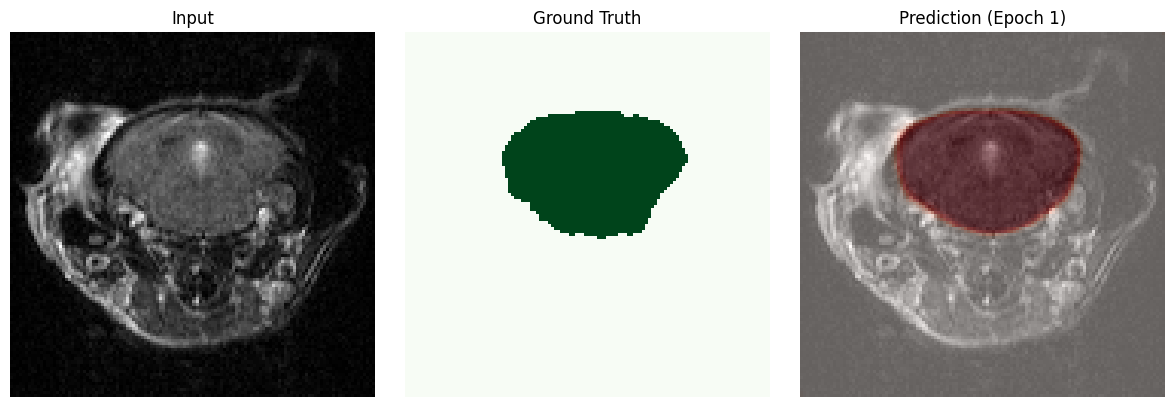

129/129 ━━━━━━━━━━━━━━━━━━━━ 66s 455ms/step - dice_coef: 0.6234 - loss: 0.5732 - val_dice_coef: 0.9330 - val_loss: 0.0942
Epoch 2/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - dice_coef: 0.9412 - loss: 0.0904

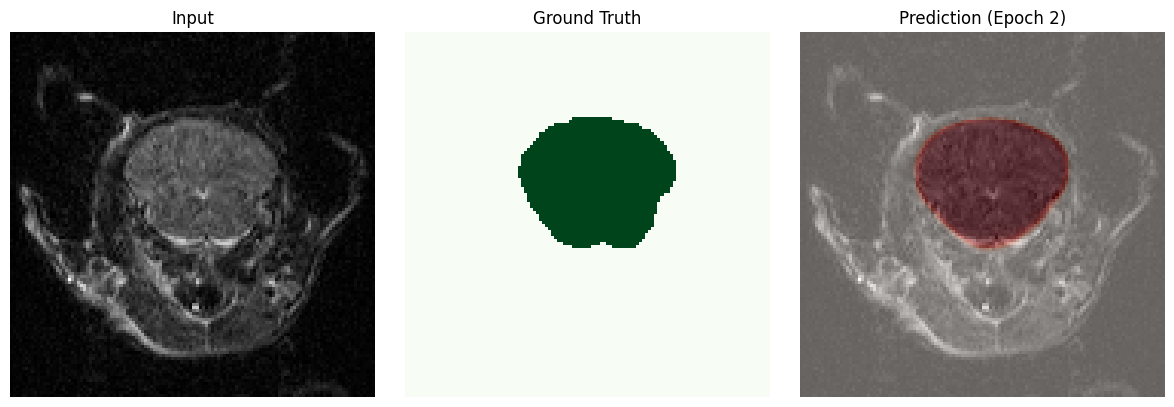

129/129 ━━━━━━━━━━━━━━━━━━━━ 64s 500ms/step - dice_coef: 0.9412 - loss: 0.0904 - val_dice_coef: 0.9434 - val_loss: 0.0830
Epoch 3/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - dice_coef: 0.9502 - loss: 0.0761

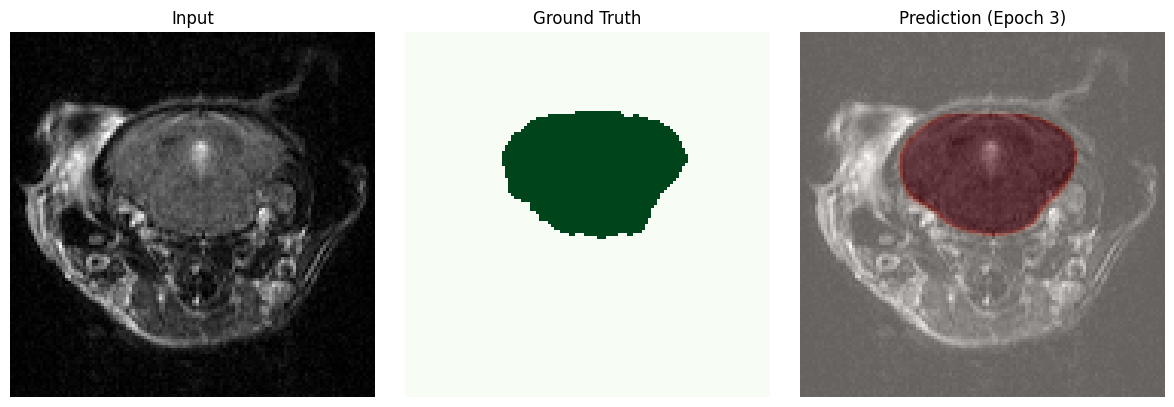

129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 466ms/step - dice_coef: 0.9502 - loss: 0.0760 - val_dice_coef: 0.9484 - val_loss: 0.0761
Epoch 4/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - dice_coef: 0.9590 - loss: 0.0646

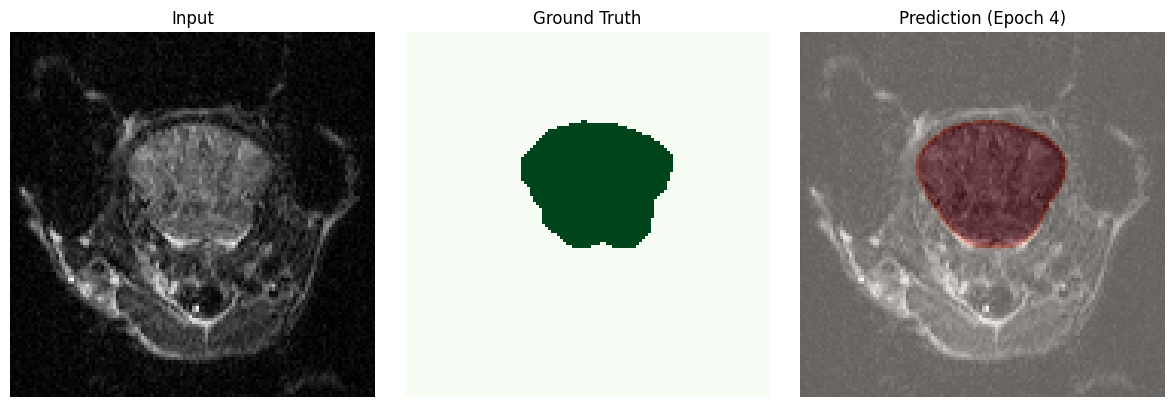

129/129 ━━━━━━━━━━━━━━━━━━━━ 62s 479ms/step - dice_coef: 0.9590 - loss: 0.0646 - val_dice_coef: 0.9579 - val_loss: 0.0607
Epoch 5/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - dice_coef: 0.9618 - loss: 0.0602

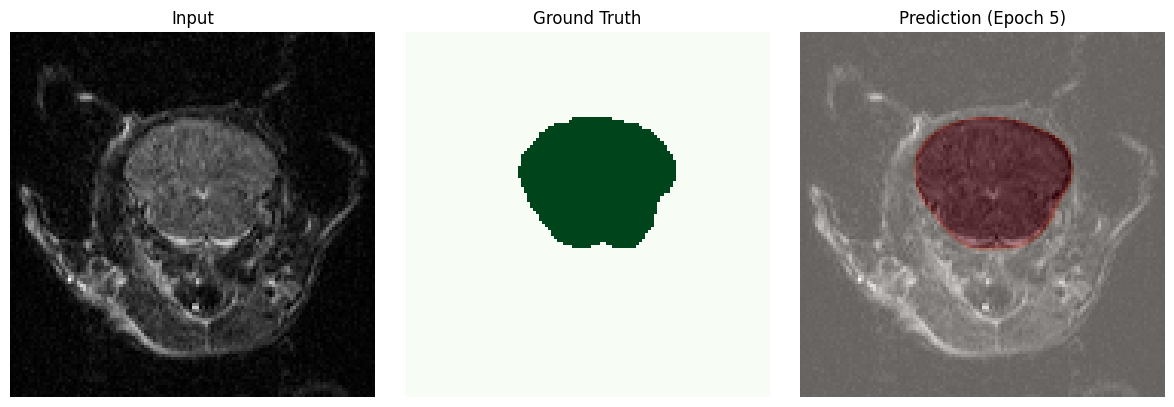

129/129 ━━━━━━━━━━━━━━━━━━━━ 61s 477ms/step - dice_coef: 0.9618 - loss: 0.0602 - val_dice_coef: 0.9607 - val_loss: 0.0578
Epoch 6/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - dice_coef: 0.9648 - loss: 0.0553

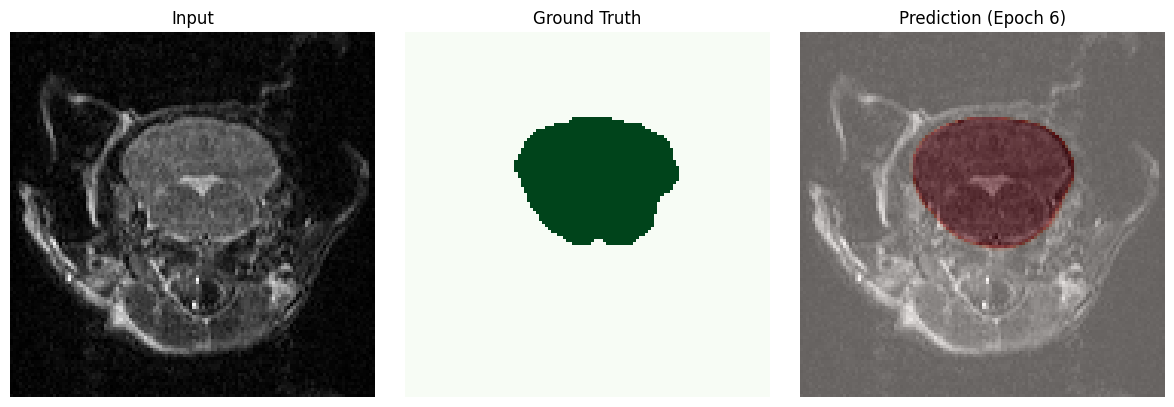

129/129 ━━━━━━━━━━━━━━━━━━━━ 63s 490ms/step - dice_coef: 0.9648 - loss: 0.0553 - val_dice_coef: 0.9581 - val_loss: 0.0633
Epoch 7/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - dice_coef: 0.9645 - loss: 0.0558

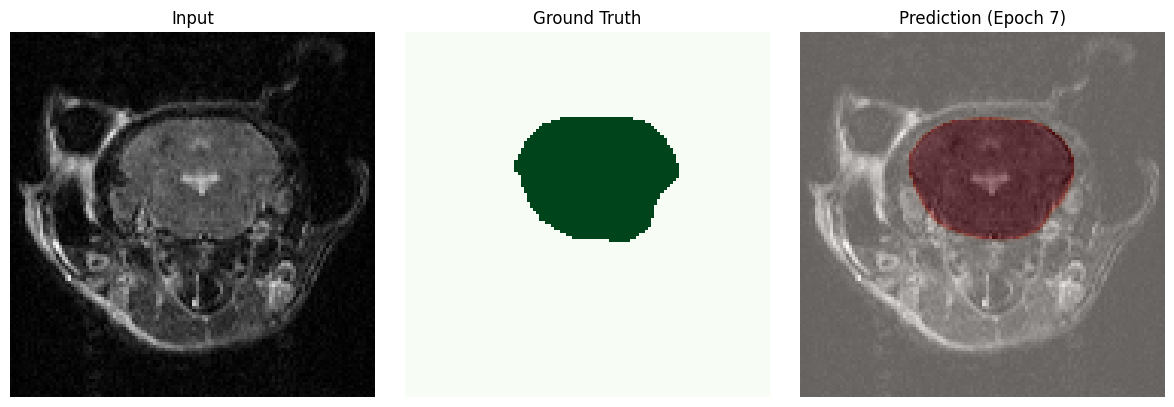

129/129 ━━━━━━━━━━━━━━━━━━━━ 62s 483ms/step - dice_coef: 0.9645 - loss: 0.0558 - val_dice_coef: 0.9595 - val_loss: 0.0611
Epoch 8/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - dice_coef: 0.9675 - loss: 0.0507

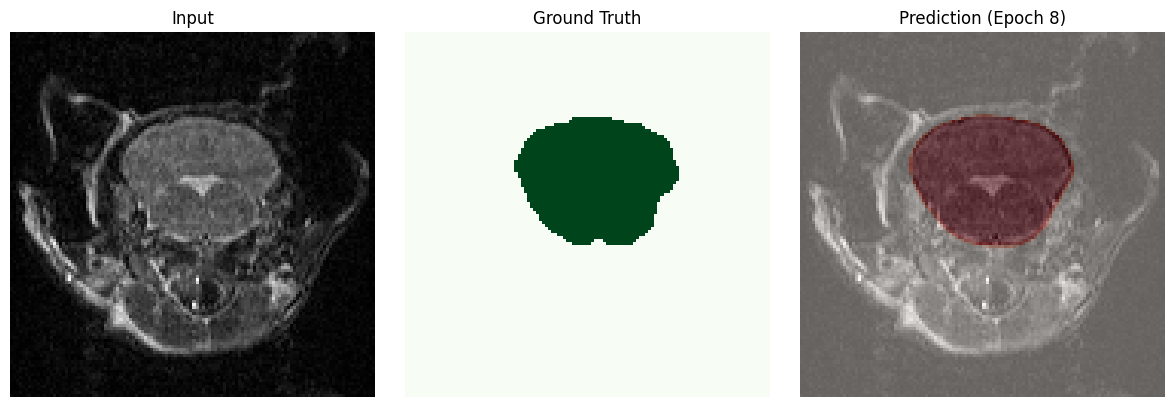

129/129 ━━━━━━━━━━━━━━━━━━━━ 50s 391ms/step - dice_coef: 0.9675 - loss: 0.0507 - val_dice_coef: 0.9637 - val_loss: 0.0541
Epoch 9/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - dice_coef: 0.9688 - loss: 0.0490

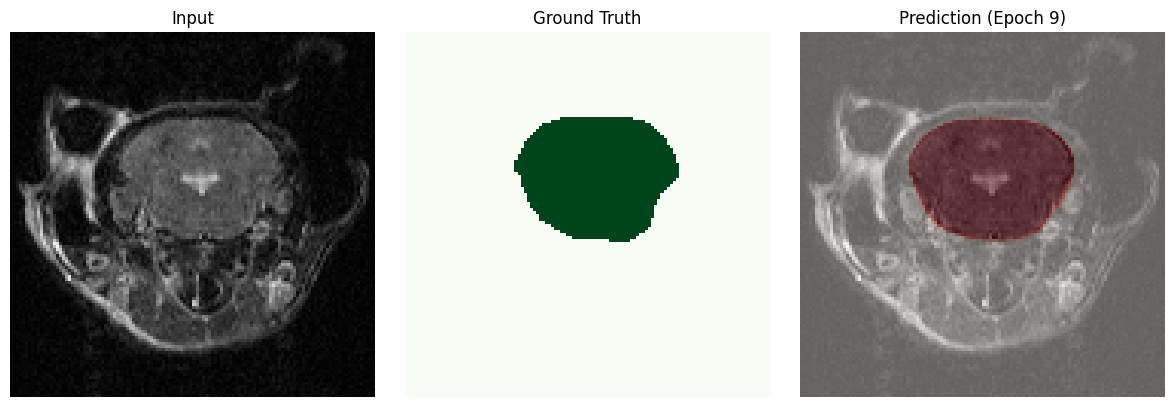

129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 413ms/step - dice_coef: 0.9688 - loss: 0.0490 - val_dice_coef: 0.9631 - val_loss: 0.0557
Epoch 10/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - dice_coef: 0.9688 - loss: 0.0494

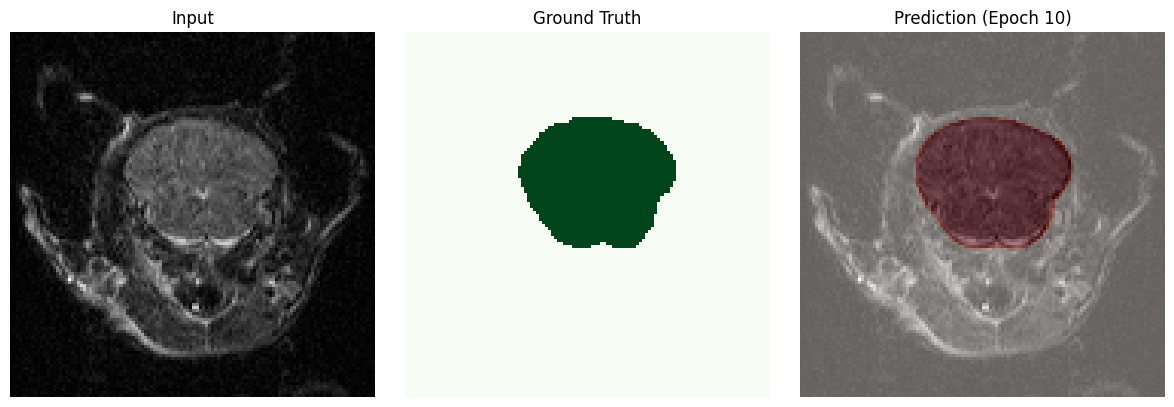

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 447ms/step - dice_coef: 0.9688 - loss: 0.0494 - val_dice_coef: 0.9629 - val_loss: 0.0560
Epoch 11/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - dice_coef: 0.9711 - loss: 0.0456

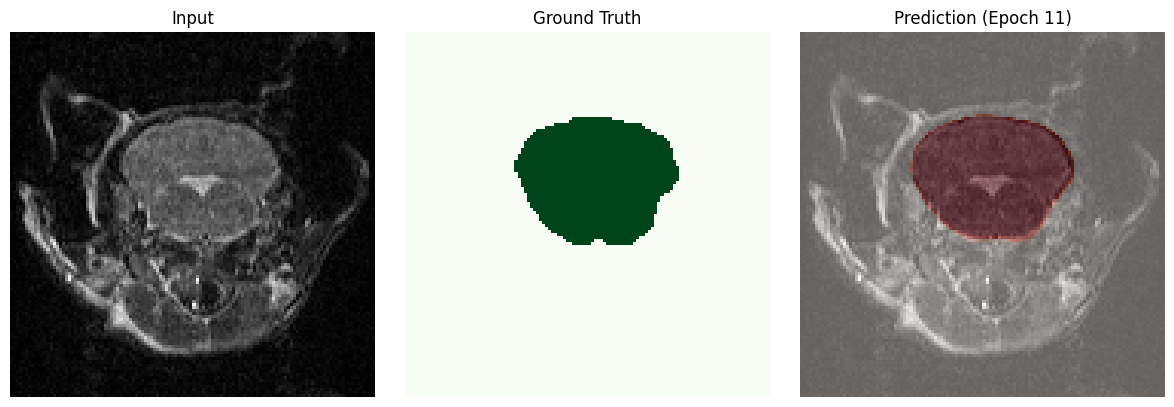

129/129 ━━━━━━━━━━━━━━━━━━━━ 70s 543ms/step - dice_coef: 0.9711 - loss: 0.0456 - val_dice_coef: 0.9639 - val_loss: 0.0554
Epoch 12/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - dice_coef: 0.9711 - loss: 0.0451

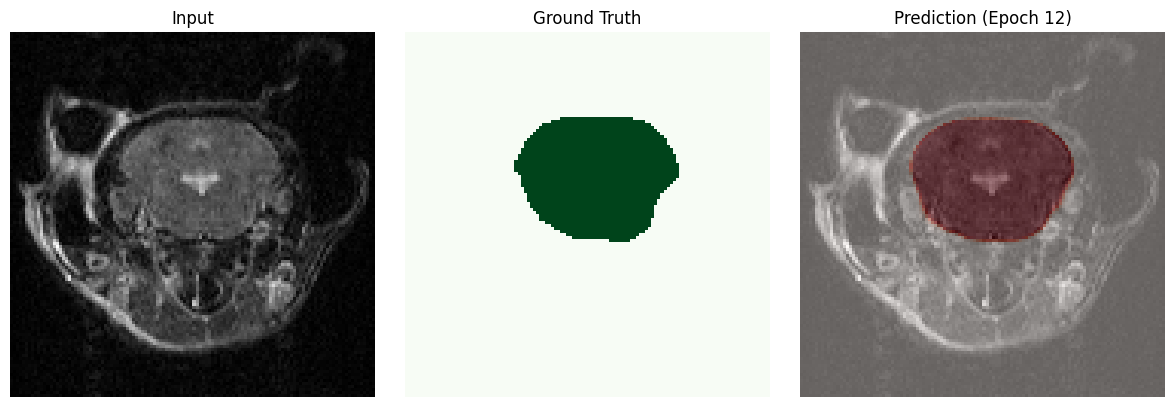

129/129 ━━━━━━━━━━━━━━━━━━━━ 57s 443ms/step - dice_coef: 0.9711 - loss: 0.0451 - val_dice_coef: 0.9623 - val_loss: 0.0574
Epoch 13/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - dice_coef: 0.9698 - loss: 0.0472

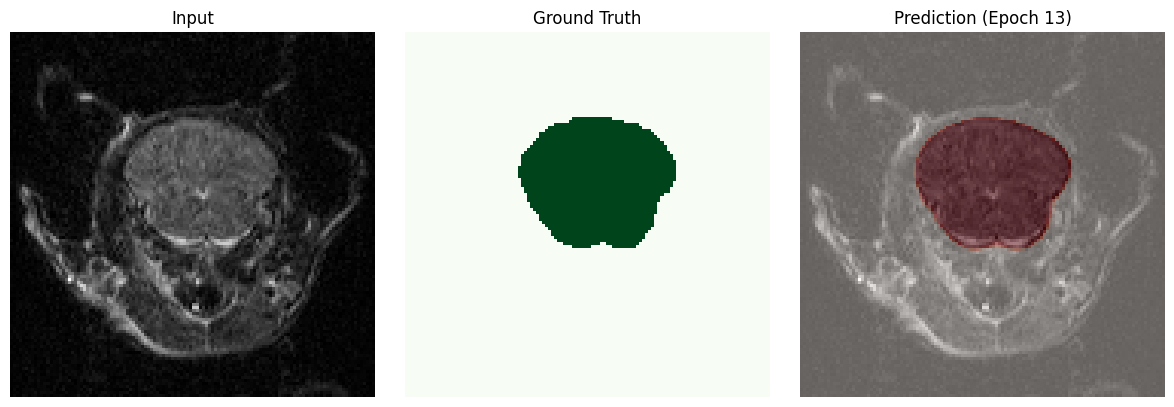

129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 461ms/step - dice_coef: 0.9698 - loss: 0.0471 - val_dice_coef: 0.9647 - val_loss: 0.0536
Epoch 14/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - dice_coef: 0.9730 - loss: 0.0419

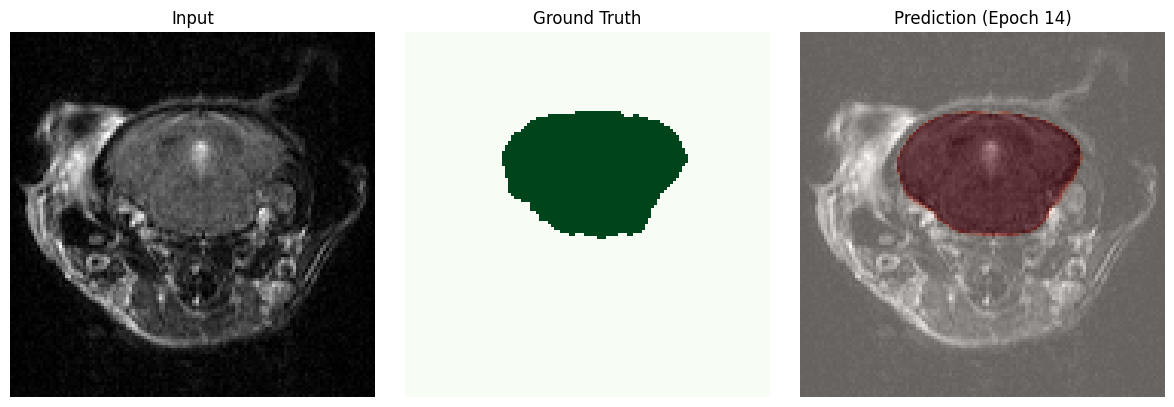

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 454ms/step - dice_coef: 0.9730 - loss: 0.0419 - val_dice_coef: 0.9663 - val_loss: 0.0522
Epoch 15/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - dice_coef: 0.9732 - loss: 0.0420

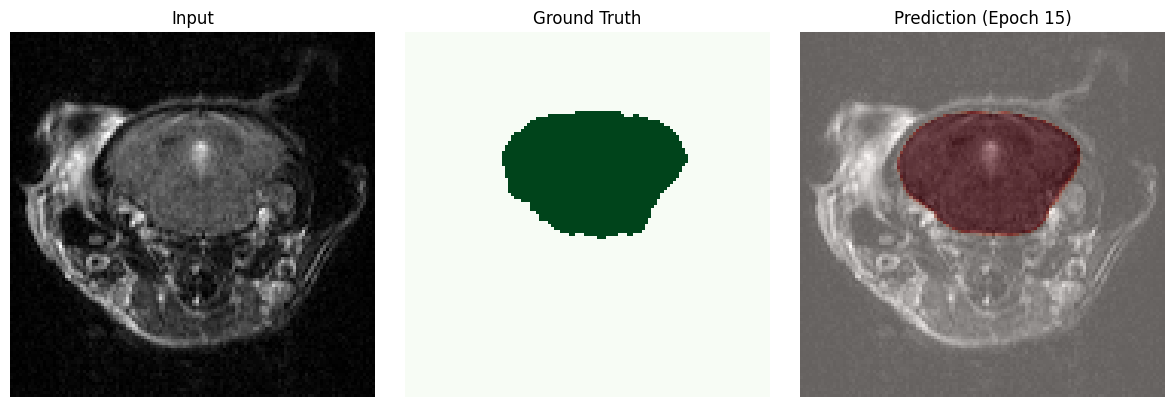

129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 383ms/step - dice_coef: 0.9732 - loss: 0.0420 - val_dice_coef: 0.9671 - val_loss: 0.0507
Epoch 16/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - dice_coef: 0.9745 - loss: 0.0397

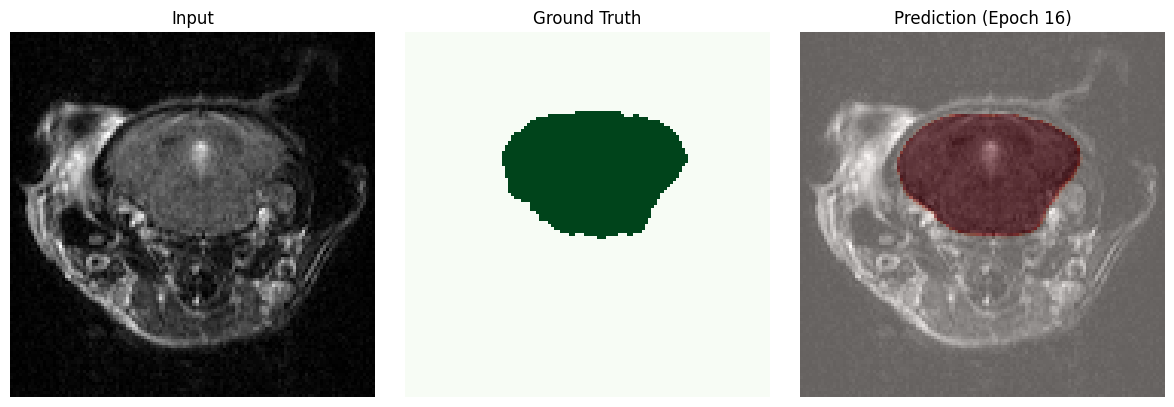

129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 366ms/step - dice_coef: 0.9744 - loss: 0.0397 - val_dice_coef: 0.9628 - val_loss: 0.0584
Epoch 17/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - dice_coef: 0.9756 - loss: 0.0379

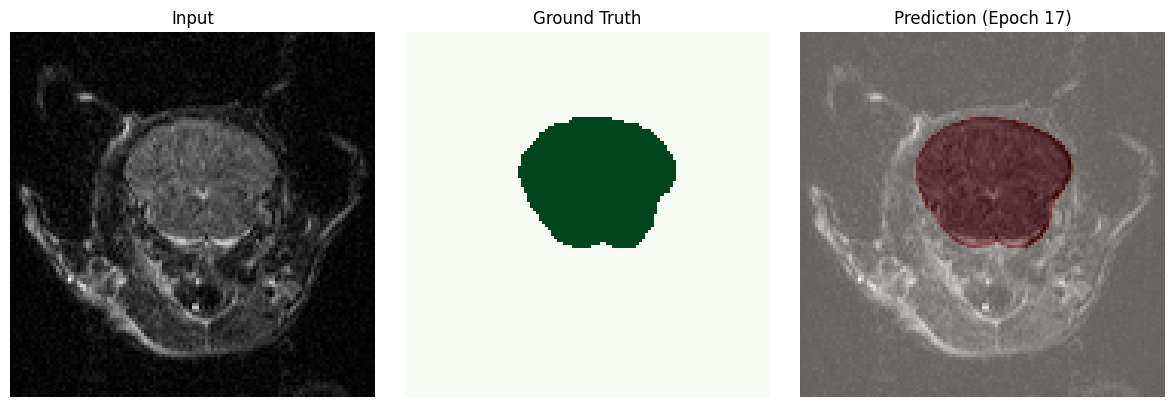

129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 370ms/step - dice_coef: 0.9756 - loss: 0.0380 - val_dice_coef: 0.9675 - val_loss: 0.0537
Epoch 18/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - dice_coef: 0.9770 - loss: 0.0356

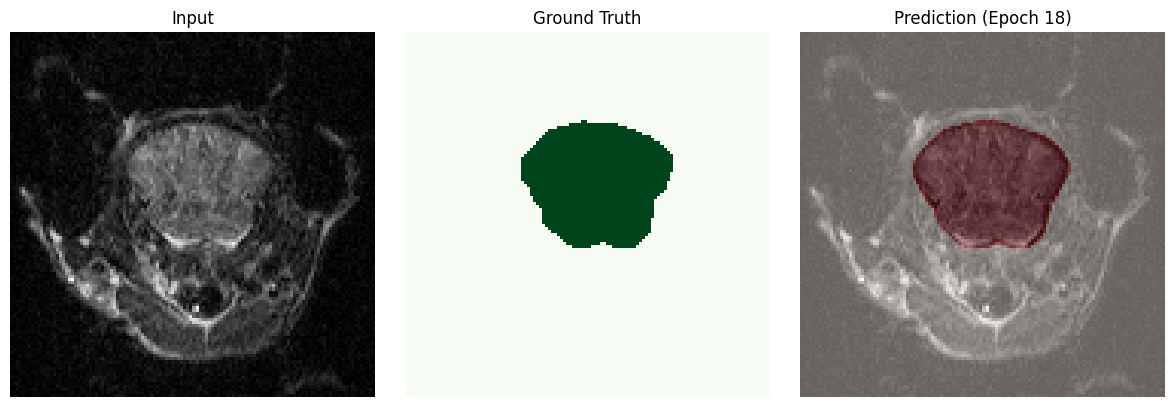

129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 364ms/step - dice_coef: 0.9770 - loss: 0.0357 - val_dice_coef: 0.9658 - val_loss: 0.0553
Epoch 19/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - dice_coef: 0.9741 - loss: 0.0405

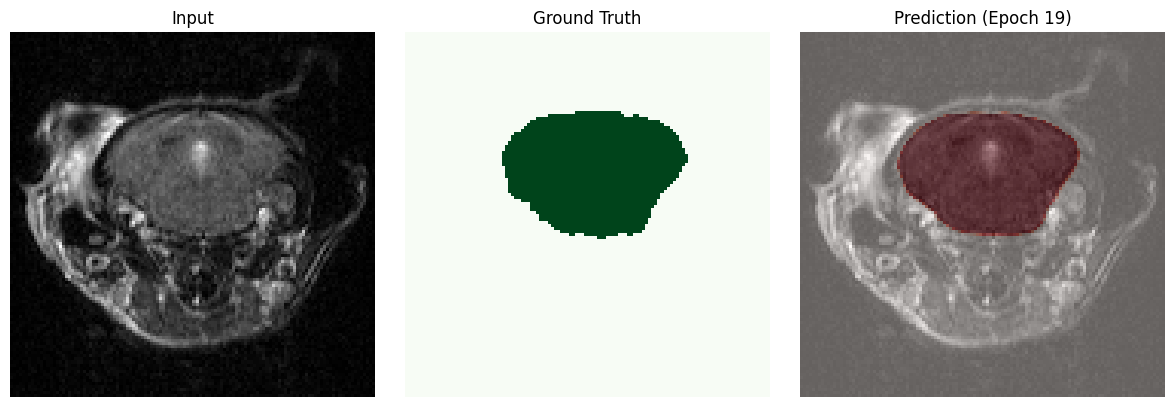

129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 369ms/step - dice_coef: 0.9741 - loss: 0.0405 - val_dice_coef: 0.9665 - val_loss: 0.0564
Epoch 20/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - dice_coef: 0.9764 - loss: 0.0371

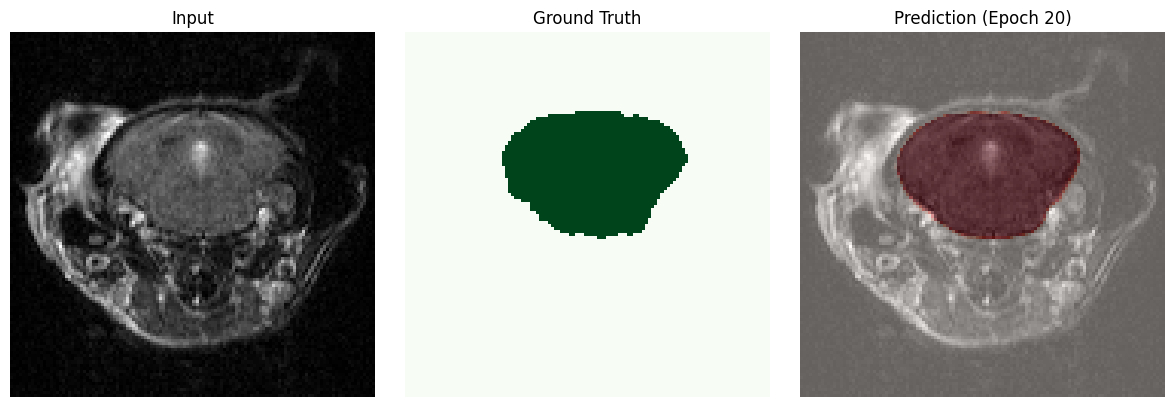

129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 375ms/step - dice_coef: 0.9763 - loss: 0.0371 - val_dice_coef: 0.9651 - val_loss: 0.0581
Epoch 21/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - dice_coef: 0.9782 - loss: 0.0339

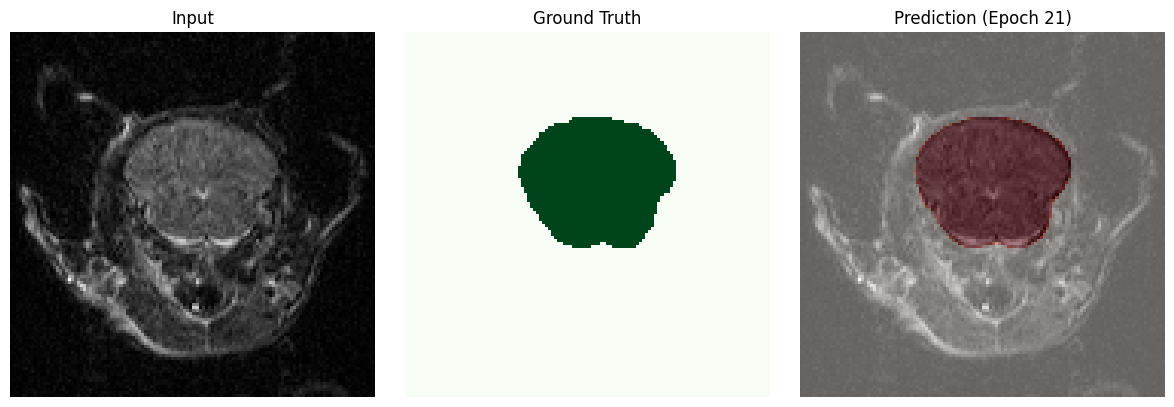

129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 367ms/step - dice_coef: 0.9782 - loss: 0.0339 - val_dice_coef: 0.9672 - val_loss: 0.0562
Epoch 22/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - dice_coef: 0.9786 - loss: 0.0336

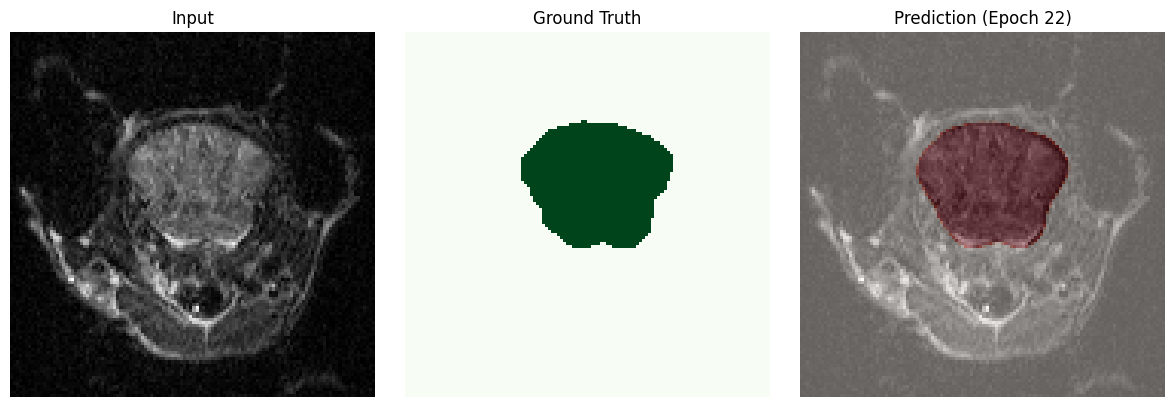

129/129 ━━━━━━━━━━━━━━━━━━━━ 50s 388ms/step - dice_coef: 0.9786 - loss: 0.0336 - val_dice_coef: 0.9646 - val_loss: 0.0604
Epoch 23/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - dice_coef: 0.9768 - loss: 0.0360

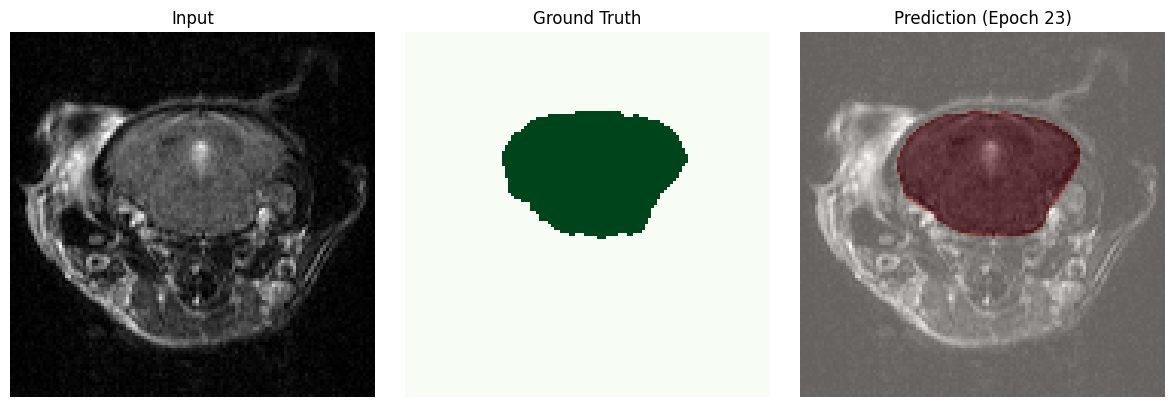

129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 469ms/step - dice_coef: 0.9768 - loss: 0.0360 - val_dice_coef: 0.9668 - val_loss: 0.0569
Epoch 24/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - dice_coef: 0.9795 - loss: 0.0320

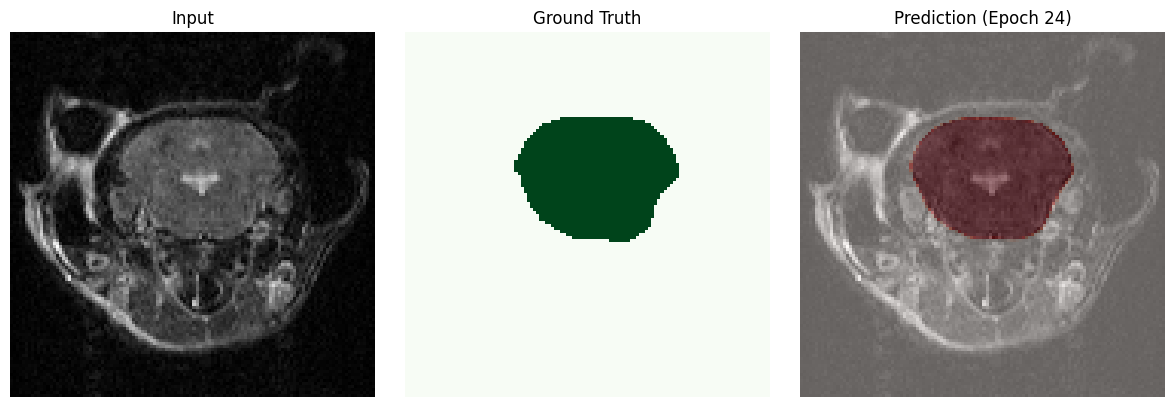

129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 467ms/step - dice_coef: 0.9795 - loss: 0.0320 - val_dice_coef: 0.9646 - val_loss: 0.0602
Epoch 25/25
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - dice_coef: 0.9778 - loss: 0.0340

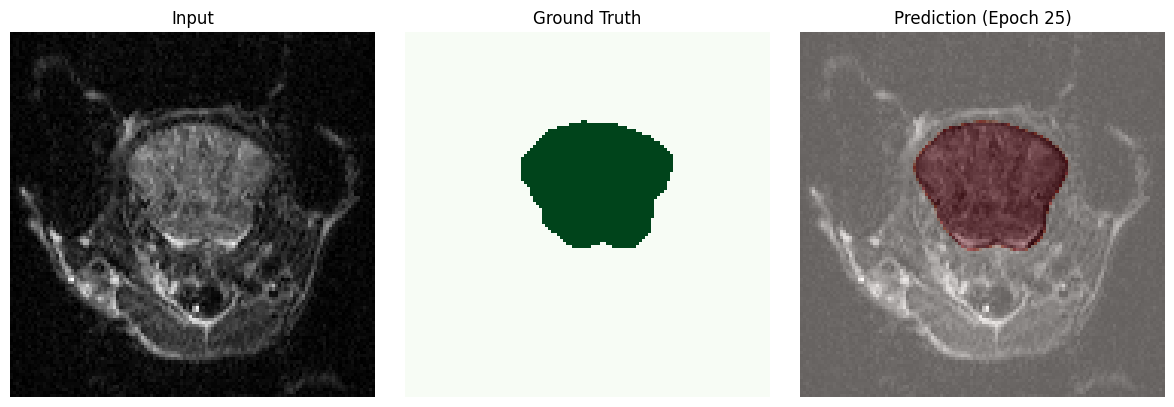

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 452ms/step - dice_coef: 0.9778 - loss: 0.0340 - val_dice_coef: 0.9675 - val_loss: 0.0564

PHASE 2: FINE-TUNE ENCODER (top 30 layers)
⚠️  ResNet50 encoder not found
Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - dice_coef: 0.9802 - loss: 0.0301

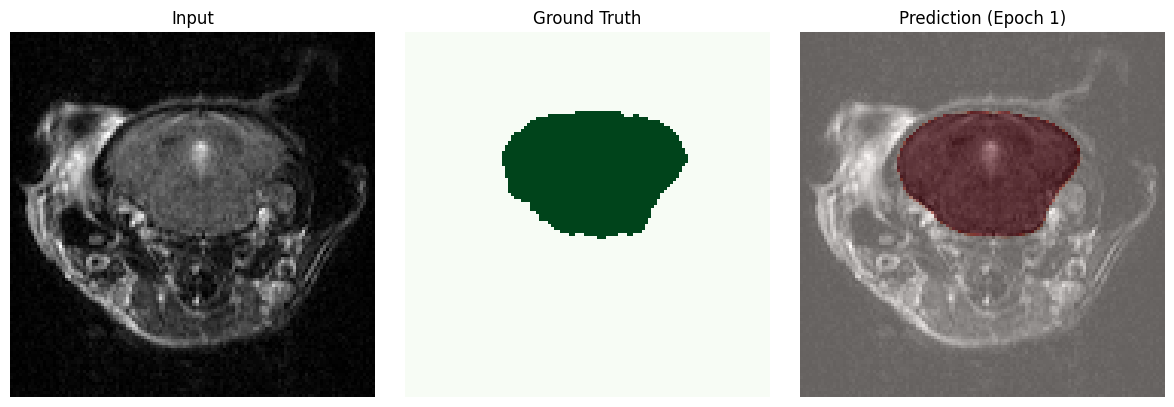

129/129 ━━━━━━━━━━━━━━━━━━━━ 68s 474ms/step - dice_coef: 0.9803 - loss: 0.0301 - val_dice_coef: 0.9685 - val_loss: 0.0556
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - dice_coef: 0.9828 - loss: 0.0265

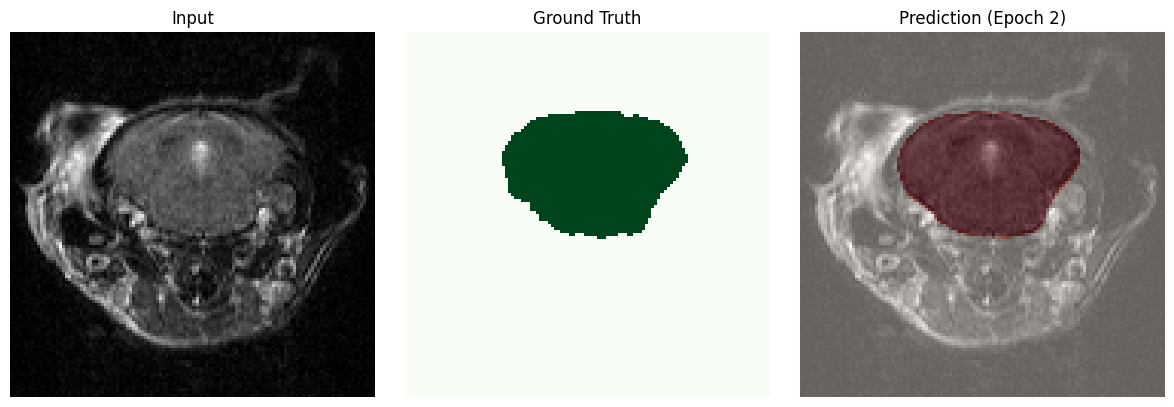

129/129 ━━━━━━━━━━━━━━━━━━━━ 57s 444ms/step - dice_coef: 0.9828 - loss: 0.0265 - val_dice_coef: 0.9685 - val_loss: 0.0571
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - dice_coef: 0.9829 - loss: 0.0261

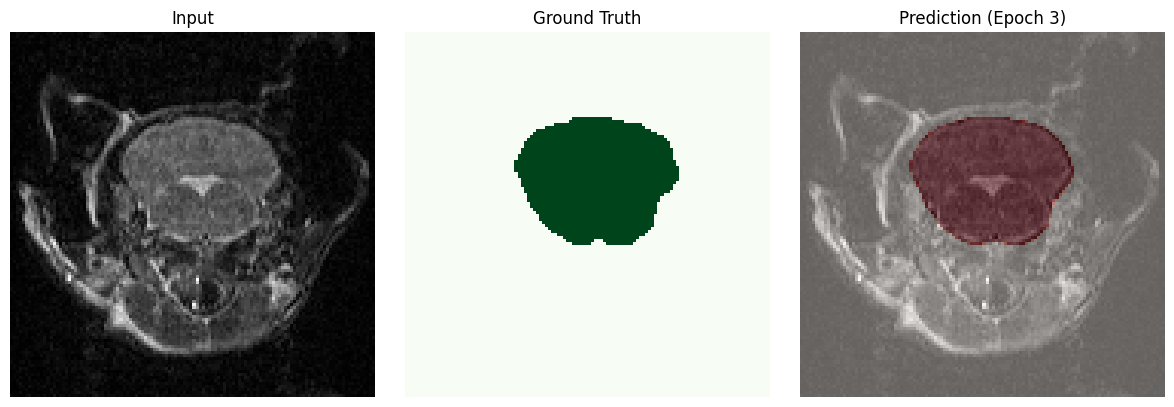

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 448ms/step - dice_coef: 0.9829 - loss: 0.0261 - val_dice_coef: 0.9689 - val_loss: 0.0572
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - dice_coef: 0.9836 - loss: 0.0250

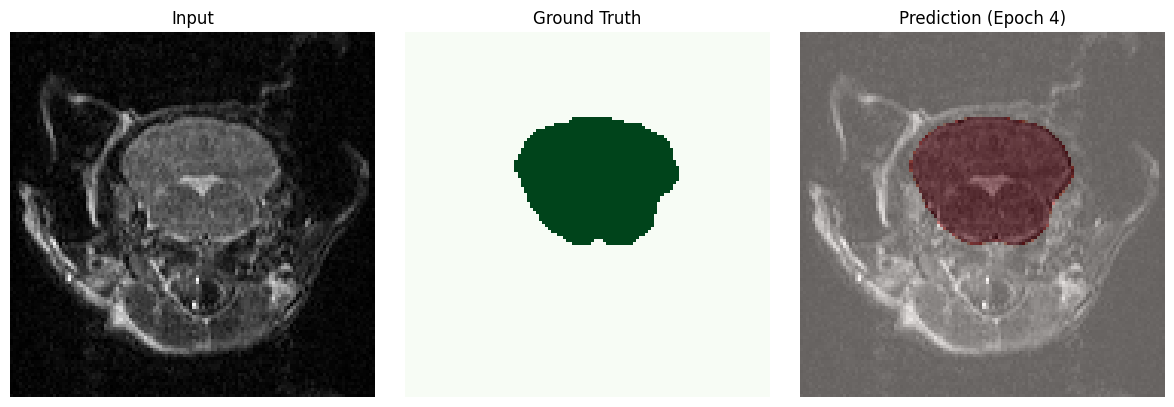

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 448ms/step - dice_coef: 0.9836 - loss: 0.0250 - val_dice_coef: 0.9684 - val_loss: 0.0584
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - dice_coef: 0.9834 - loss: 0.0256

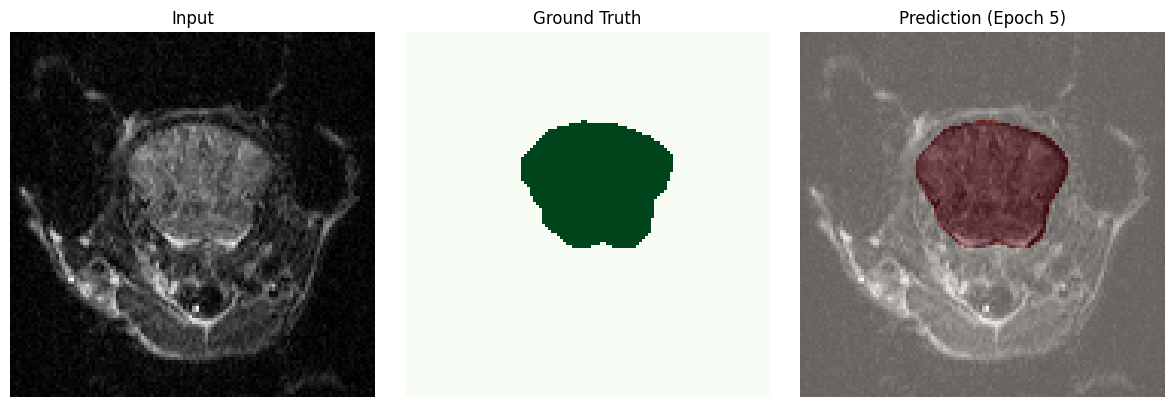

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 446ms/step - dice_coef: 0.9834 - loss: 0.0256 - val_dice_coef: 0.9687 - val_loss: 0.0588
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - dice_coef: 0.9829 - loss: 0.0262

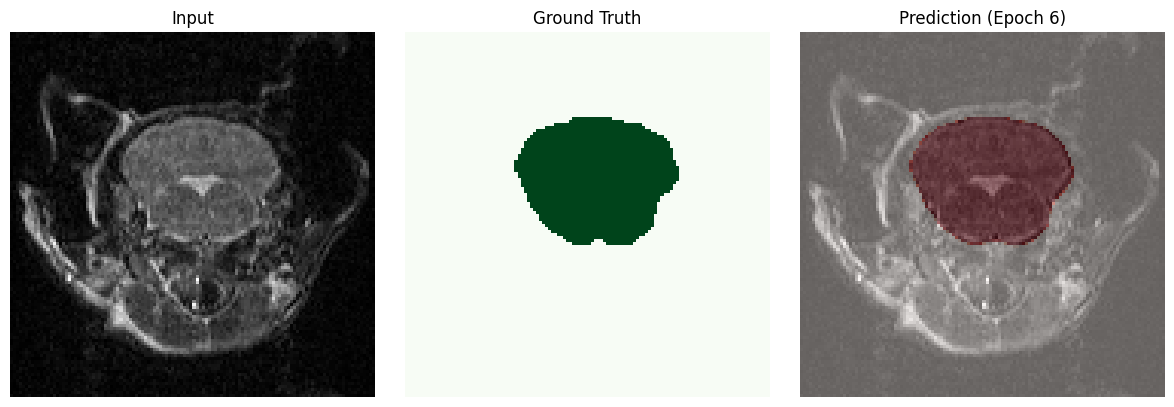

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - dice_coef: 0.9829 - loss: 0.0262 - val_dice_coef: 0.9681 - val_loss: 0.0593
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - dice_coef: 0.9844 - loss: 0.0240

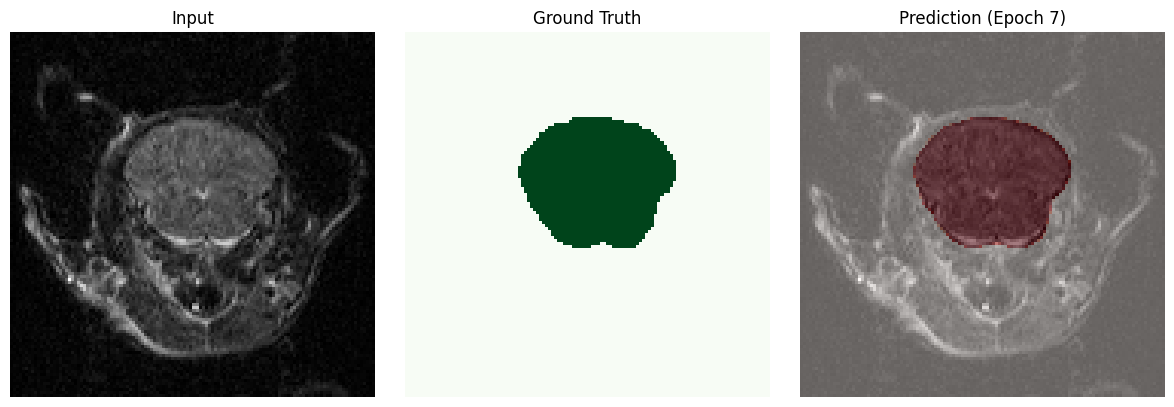

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - dice_coef: 0.9844 - loss: 0.0240 - val_dice_coef: 0.9677 - val_loss: 0.0610
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - dice_coef: 0.9839 - loss: 0.0245

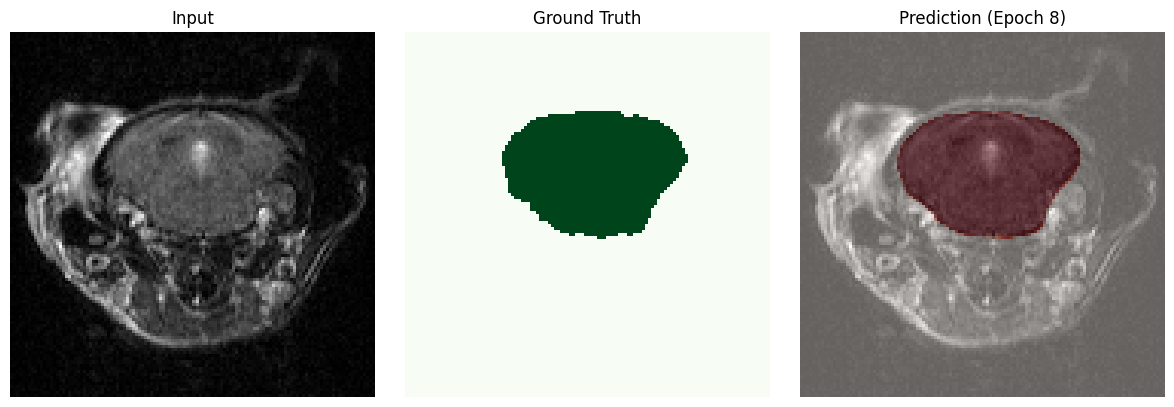

129/129 ━━━━━━━━━━━━━━━━━━━━ 57s 445ms/step - dice_coef: 0.9839 - loss: 0.0245 - val_dice_coef: 0.9684 - val_loss: 0.0573
Epoch 9/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - dice_coef: 0.9838 - loss: 0.0247

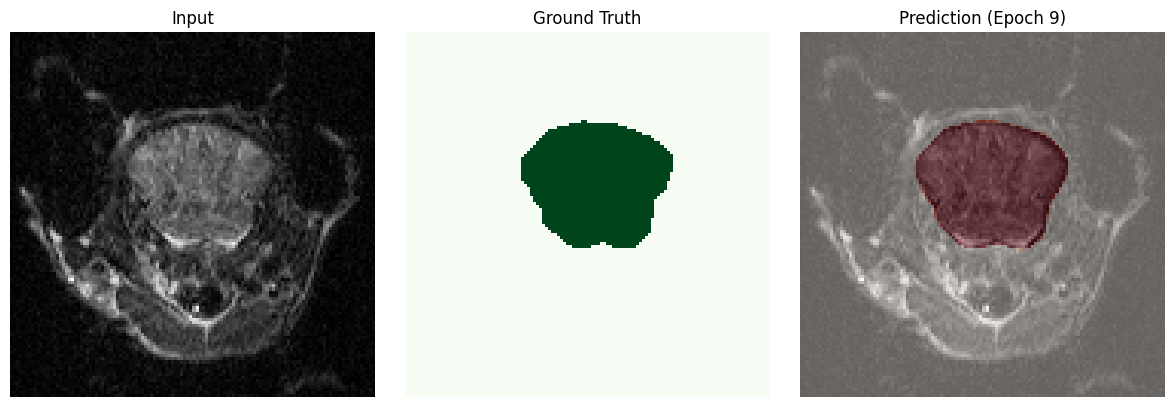

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 450ms/step - dice_coef: 0.9838 - loss: 0.0247 - val_dice_coef: 0.9684 - val_loss: 0.0587
Epoch 10/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - dice_coef: 0.9856 - loss: 0.0221

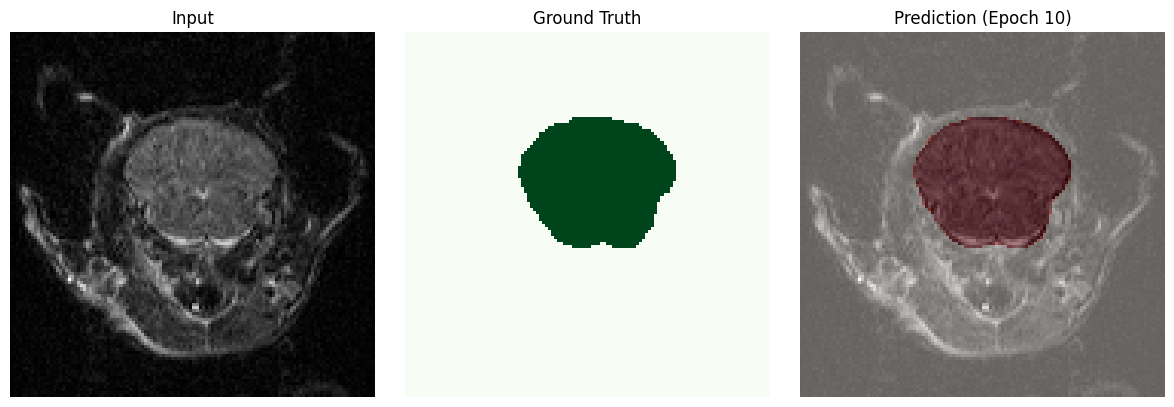

129/129 ━━━━━━━━━━━━━━━━━━━━ 58s 448ms/step - dice_coef: 0.9856 - loss: 0.0222 - val_dice_coef: 0.9690 - val_loss: 0.0586

✅ Training complete!


In [10]:
# =============================================================
# 6. TRAIN MODEL - PHASE 1 & 2
# =============================================================

model = unet_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

callback_vis = DisplayPredictions(X[:5], Y[:5])

print("=" * 70)
print("PHASE 1: ENCODER FROZEN (learn decoder only)")
print("=" * 70)
print(f"Training on {len(X)} samples with validation split = 0.15\n")

history_1 = model.fit(
    X, Y,
    batch_size=BATCH_SIZE,
    epochs=25,
    validation_split=0.15,
    verbose=1,
    callbacks=[callback_vis]
)

print("\n" + "=" * 70)
print("PHASE 2: FINE-TUNE ENCODER (top 30 layers)")
print("=" * 70)

unfreeze_pretrained_encoder(model, last_n_layers=30)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

history_2 = model.fit(
    X, Y,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.15,
    verbose=1,
    callbacks=[callback_vis]
)

print("\n✅ Training complete!")

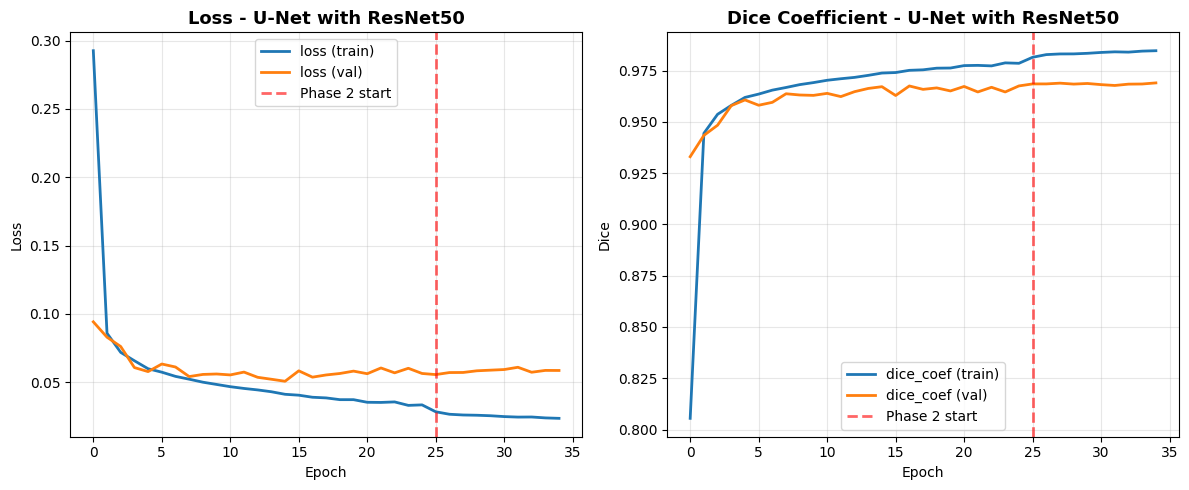


📊 FINAL RESULTS
   Validation Dice:  0.9690
   Validation Loss:  0.0586
   Best Dice: 0.9690


In [11]:
# =============================================================
# 7. PLOT TRAINING CURVES
# =============================================================

loss_total = history_1.history['loss'] + history_2.history['loss']
val_loss_total = history_1.history['val_loss'] + history_2.history['val_loss']
dice_total = history_1.history['dice_coef'] + history_2.history['dice_coef']
val_dice_total = history_1.history['val_dice_coef'] + history_2.history['val_dice_coef']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_total, label='loss (train)', linewidth=2)
plt.plot(val_loss_total, label='loss (val)', linewidth=2)
plt.axvline(x=25, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Phase 2 start')
plt.title("Loss - U-Net with ResNet50", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(dice_total, label='dice_coef (train)', linewidth=2)
plt.plot(val_dice_total, label='dice_coef (val)', linewidth=2)
plt.axvline(x=25, color='red', linestyle='--', alpha=0.6, linewidth=2, label='Phase 2 start')
plt.title("Dice Coefficient - U-Net with ResNet50", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 FINAL RESULTS")
print(f"   Validation Dice:  {val_dice_total[-1]:.4f}")
print(f"   Validation Loss:  {val_loss_total[-1]:.4f}")
print(f"   Best Dice: {max(val_dice_total):.4f}")

In [12]:
# =============================================================
# 8. SAVE MODEL
# =============================================================

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, MODEL_NAME)
model.save(model_path)

print(f"💾 Modelo guardado en: {model_path}")


💾 Model saved successfully!
   Path: models\brain_segmentatio_model_RadImageNET.h5
   Size: 90.99 MB

📊 Final Results:
   ✅ Validation Dice:   0.9690
   ✅ Validation Loss:   0.0586
   ✅ Best Dice: 0.9690


In [15]:
# =============================================================
# 9. SAVE MODEL
# =============================================================

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save with timestamp to track experiments
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(MODEL_DIR, f"brain_unet_radimagenet_isquemia_{timestamp}.h5")

model_radimagenet.save(model_path)

print(f"💾 Model saved successfully!")
print(f"   Path: {model_path}")
print(f"   Size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

NameError: name 'model_radimagenet' is not defined

## 📊 Model Comparison

### ResNet50 vs MobileNetV2 Transfer Learning

**ResNet50 (this notebook)**
- Encoder: 151M parameters
- Pretraining: RadImageNet
- Skip connections: 4 layers
- Complexity: Higher, more powerful

**MobileNetV2 (UNET_PREENTRENADA_Isquemia.ipynb)**
- Encoder: ~3.5M parameters  
- Pretraining: RadImageNet
- Skip connections: 3 layers
- Complexity: Lower, faster inference

### Which to use?

- Use **ResNet50** if: You need best accuracy and have time for training
- Use **MobileNetV2** if: You need fast inference or have limited GPU memory

Both are trained with the same two-phase strategy (frozen → fine-tuned) on the same dataset.

### For Your Thesis

> "We trained a U-Net with a ResNet50 encoder pretrained on RadImageNet. The encoder was initially frozen and only the decoder was learned for 25 epochs. Subsequently, the top 30 encoder layers were fine-tuned with a reduced learning rate (1e-5) for 10 additional epochs to adapt to the target ischemia segmentation domain."